# Phase 2 — Exploratory Data Analysis: China EPU × CSI 300

**Dataset:** `cepu_csi300_merged.csv` (monthly, generated in Phase 1)  
**Objective:** EDA of the merged dataset — distributions, correlations, lead-lag structure, and regime analysis — prior to any predictive modelling.  
**Scope:** Association analysis only. No causal claims. No machine-learning models.

---

## 0. Setup

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from pathlib import Path
import warnings

warnings.filterwarnings('ignore')

# ── Plot style ──────────────────────────────────────────────────────
sns.set_style('whitegrid')
plt.rcParams.update({
    'figure.figsize': (14, 5),
    'axes.titlesize': 14,
    'axes.labelsize': 12,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
    'legend.fontsize': 11,
    'figure.dpi': 120,
})

COLORS = {
    'epu':    '#1f77b4',
    'vol':    '#d62728',
    'ret':    '#2ca02c',
    'shock':  '#ff7f0e',
}

# ── Data paths ──────────────────────────────────────────────────────
DATA_PROCESSED = Path('../../../../data/processed')

print('Libraries loaded ✓')

Libraries loaded ✓


In [7]:
# ── Load dataset ────────────────────────────────────────────────────
df = pd.read_csv(DATA_PROCESSED / 'cepu_csi300_merged.csv', parse_dates=['Date'])
df.sort_values('Date', inplace=True)
df.reset_index(drop=True, inplace=True)

# ── Fill derived columns if missing ─────────────────────────────────
# CNEPU_MA12: 12-month centred moving average of CNEPU
if df['CNEPU_MA12'].isna().all() or df['CNEPU_MA12'].isna().sum() > len(df) * 0.5:
    df['CNEPU_MA12'] = df['CNEPU'].rolling(12, min_periods=12).mean()
    print('CNEPU_MA12 recalculated (rolling mean 12m).')

# CNEPU_Std12: 12-month rolling standard deviation of CNEPU
if df['CNEPU_Std12'].isna().all() or df['CNEPU_Std12'].isna().sum() > len(df) * 0.5:
    df['CNEPU_Std12'] = df['CNEPU'].rolling(12, min_periods=12).std()
    print('CNEPU_Std12 recalculated (rolling std 12m).')

# CSI_Vol3m / CSI_Vol6m: rolling mean of CSI_Vol
if 'CSI_Vol3m' not in df.columns or df['CSI_Vol3m'].isna().sum() > len(df) * 0.5:
    df['CSI_Vol3m'] = df['CSI_Vol'].rolling(3, min_periods=3).mean()
    print('CSI_Vol3m recalculated (3m rolling mean of CSI_Vol).')

if 'CSI_Vol6m' not in df.columns or df['CSI_Vol6m'].isna().sum() > len(df) * 0.5:
    df['CSI_Vol6m'] = df['CSI_Vol'].rolling(6, min_periods=6).mean()
    print('CSI_Vol6m recalculated (6m rolling mean of CSI_Vol).')

# Set Date as index (keep column too)
df.set_index('Date', inplace=True)
df.index.name = 'Date'

print(f'Dataset loaded: {df.shape[0]} observations, {df.shape[1]} columns')
print(f'Date range: {df.index.min().date()} → {df.index.max().date()}')

Dataset loaded: 247 observations, 16 columns
Date range: 2005-01-01 → 2025-07-01


---
## 1. Data Overview — Quality and Structure

Before any analysis we verify the dataset integrity: types, missing values, temporal coverage, and monthly frequency. A consistent monthly grid is critical because later lead-lag and rolling-window computations assume equally spaced observations.

In [10]:
df.info()
df.describe().round(4)

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 247 entries, 2005-01-01 to 2025-07-01
Data columns (total 16 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   year              247 non-null    int64  
 1   month             247 non-null    int64  
 2   CNEPU             247 non-null    float64
 3   ΔCNEPU            246 non-null    float64
 4   CNEPU_MA12        236 non-null    float64
 5   CNEPU_Std12       236 non-null    float64
 6   CSI_Close_Avg     247 non-null    float64
 7   CSI_Close_Last    247 non-null    float64
 8   CSI_Open_First    247 non-null    float64
 9   CSI_High_Max      247 non-null    float64
 10  CSI_Low_Min       247 non-null    float64
 11  CSI_Return        246 non-null    float64
 12  CSI_Vol           247 non-null    float64
 13  CSI_Vol3m         244 non-null    float64
 14  CSI_Vol6m         241 non-null    float64
 15  CSI_Trading_Days  247 non-null    int64  
dtypes: float64(13), int64(3)


,year,month,CNEPU,ΔCNEPU,CNEPU_MA12,CNEPU_Std12,CSI_Close_Avg,CSI_Close_Last,CSI_Open_First,CSI_High_Max,CSI_Low_Min,CSI_Return,CSI_Vol,CSI_Vol3m,CSI_Vol6m,CSI_Trading_Days
count,247.0000,247.0000,247.0000,246.0000,236.0000,236.0000,247.0000,247.0000,247.0000,247.0000,247.0000,246.0000,247.0000,244.0000,241.0000,247.0000
mean,2014.7976,6.4291,182.0967,1.2060,180.7973,50.6769,3259.3269,3253.9470,3245.0245,3418.0108,3084.0583,0.0060,0.0142,0.0608,0.0661,20.2389
std,5.9571,3.4515,123.9373,73.8880,105.3828,35.1800,1068.0753,1065.5266,1077.7527,1121.4505,1019.2097,0.0792,0.0073,0.0426,0.0342,2.2514
min,2005.0000,1.0000,23.7164,-273.1702,48.2766,10.9113,853.1400,855.9500,855.2100,886.7400,807.7800,-0.2991,0.0027,0.0035,0.0162,13.0000
25%,2010.0000,3.0000,95.0771,-32.4913,104.4446,22.7992,2557.8550,2522.2350,2535.0750,2687.3450,2420.2850,-0.0322,0.0092,0.0302,0.0416,19.0000
50%,2015.0000,6.0000,133.9478,1.6580,125.5460,31.9578,3348.9972,3431.1100,3361.5600,3543.6100,3191.4000,0.0059,0.0120,0.0510,0.0579,21.0000
75%,2020.0000,9.0000,248.9792,30.9733,280.5413,74.4818,3927.2258,3894.7700,3899.5150,4094.5250,3783.9700,0.0482,0.0177,0.0756,0.0847,22.0000
max,2025.0000,12.0000,661.8280,283.9710,411.4409,136.8978,5632.6144,5688.5400,5703.2800,5930.9100,5318.8600,0.2463,0.0391,0.2478,0.1671,23.0000


In [11]:
# ── Temporal range and frequency check ──────────────────────────────
date_range = pd.date_range(df.index.min(), df.index.max(), freq='MS')
missing_months = date_range.difference(df.index)

print(f'Min date : {df.index.min().date()}')
print(f'Max date : {df.index.max().date()}')
print(f'Expected months : {len(date_range)}')
print(f'Actual months   : {len(df)}')
print(f'Gaps (missing)  : {len(missing_months)}')
if len(missing_months) > 0:
    print('Missing months:', missing_months.strftime('%Y-%m').tolist())

# ── Missing values summary ──────────────────────────────────────────
missing = pd.DataFrame({
    'missing_count': df.isna().sum(),
    'missing_pct': (df.isna().mean() * 100).round(2)
})
missing = missing.sort_values('missing_count', ascending=False)
display(missing)

Min date : 2005-01-01
Max date : 2025-07-01
Expected months : 247
Actual months   : 247
Gaps (missing)  : 0


,missing_count,missing_pct
CNEPU_MA12,11,4.45
CNEPU_Std12,11,4.45
CSI_Vol6m,6,2.43
CSI_Vol3m,3,1.21
ΔCNEPU,1,0.40
CSI_Return,1,0.40
year,0,0.00
month,0,0.00
CNEPU,0,0.00
CSI_Close_Avg,0,0.00


> **Note on frequency:** Monthly granularity is a deliberate choice for this study. The EPU index is published monthly, so aggregating CSI 300 to monthly avoids information leakage from higher-frequency market data. Rolling-window statistics computed later (MA12, Vol3m, Vol6m) assume no gaps in the monthly grid.

---
## 2. Time-Series Visualisation of Core Variables

We inspect the main series individually to identify trends, structural breaks, outlier spikes, and regime changes. Vertical reference lines mark well-known crisis episodes:
- **Sep 2008** — Global Financial Crisis (Lehman Brothers collapse)
- **Jun 2015** — Chinese stock-market crash
- **Mar 2020** — COVID-19 pandemic onset

In [13]:
# ── Helper: vertical crisis lines ──────────────────────────────────
CRISES = {
    '2008-09': 'GFC',
    '2015-06': 'China crash',
    '2020-03': 'COVID-19',
}

def add_crisis_lines(ax):
    """Add dashed vertical lines for major crisis dates."""
    for date_str, label in CRISES.items():
        dt = pd.Timestamp(date_str)
        if df.index.min() <= dt <= df.index.max():
            ax.axvline(dt, color='grey', linestyle='--', alpha=0.6, linewidth=0.9)
            ax.text(dt, ax.get_ylim()[1] * 0.97, f' {label}',
                    fontsize=8, color='grey', rotation=90,
                    va='top', ha='right')

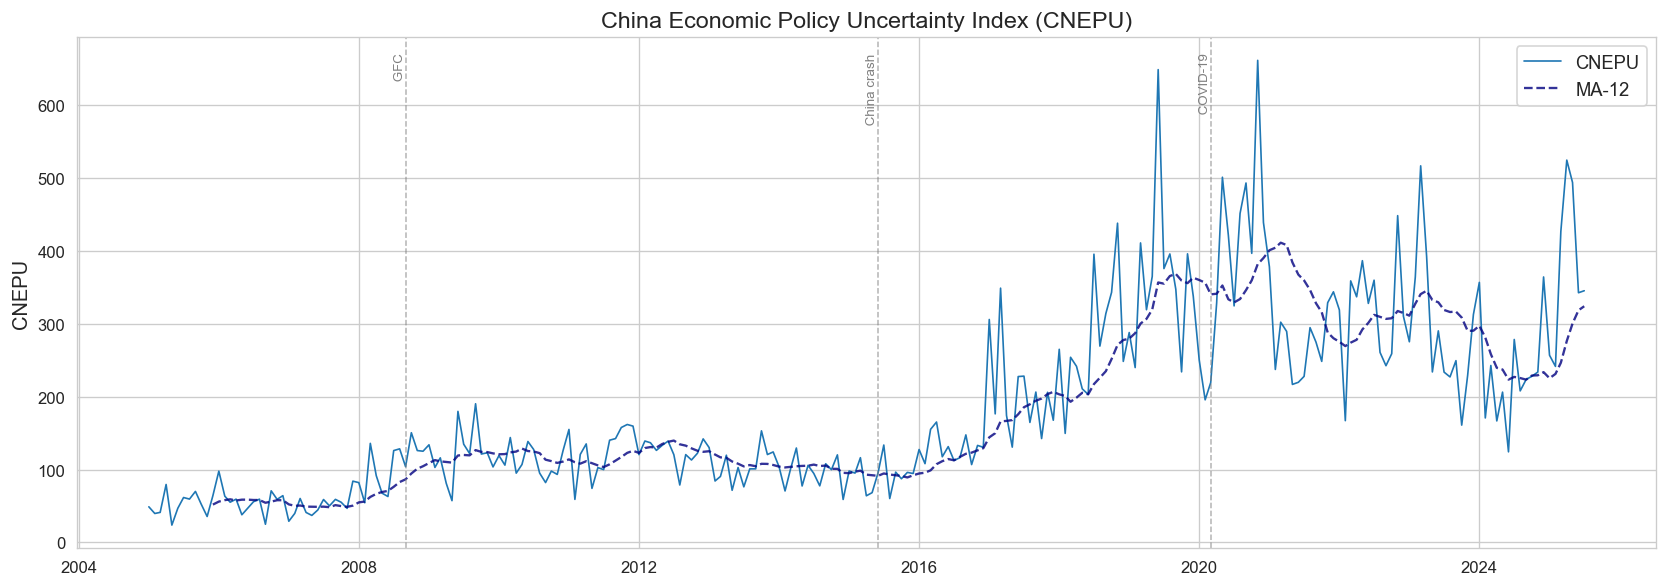

In [14]:
# ── 2a. CNEPU (level) ──────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(df.index, df['CNEPU'], color=COLORS['epu'], linewidth=1.0, label='CNEPU')
if 'CNEPU_MA12' in df.columns:
    ax.plot(df.index, df['CNEPU_MA12'], color='navy', linewidth=1.4,
            linestyle='--', label='MA-12', alpha=0.8)
add_crisis_lines(ax)
ax.set_title('China Economic Policy Uncertainty Index (CNEPU)')
ax.set_ylabel('CNEPU')
ax.legend()
plt.tight_layout()
plt.show()

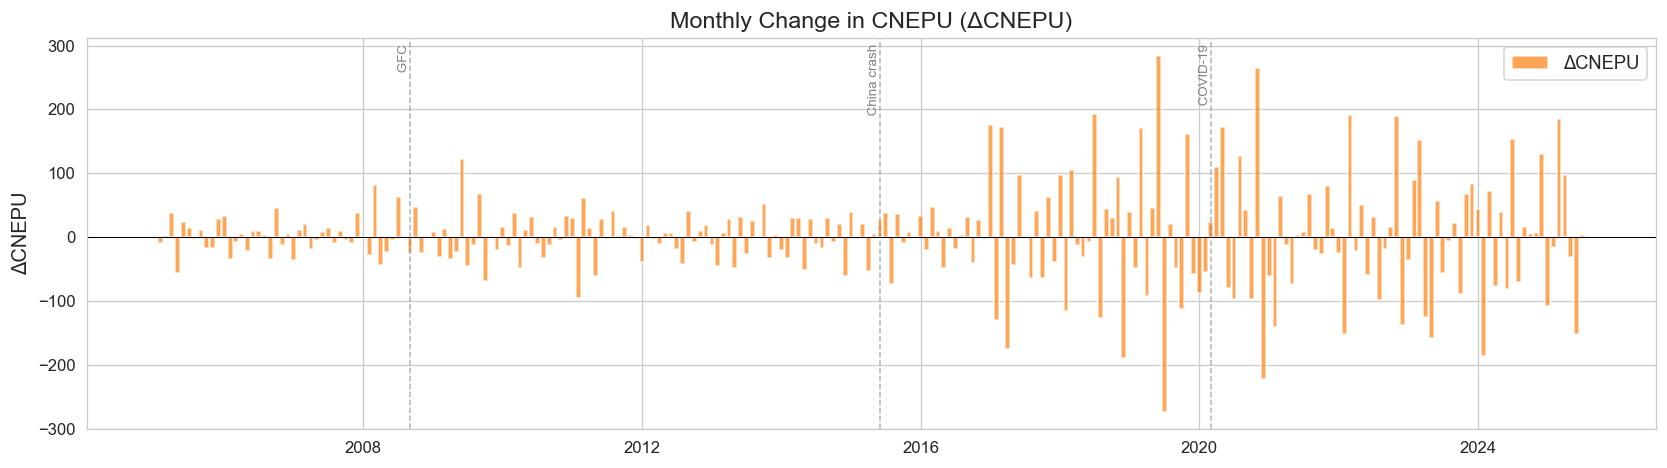

In [15]:
# ── 2b. ΔCNEPU (shocks) ────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(14, 4))
ax.bar(df.index, df['ΔCNEPU'], width=25, color=COLORS['shock'], alpha=0.7, label='ΔCNEPU')
ax.axhline(0, color='black', linewidth=0.6)
add_crisis_lines(ax)
ax.set_title('Monthly Change in CNEPU (ΔCNEPU)')
ax.set_ylabel('ΔCNEPU')
ax.legend()
plt.tight_layout()
plt.show()

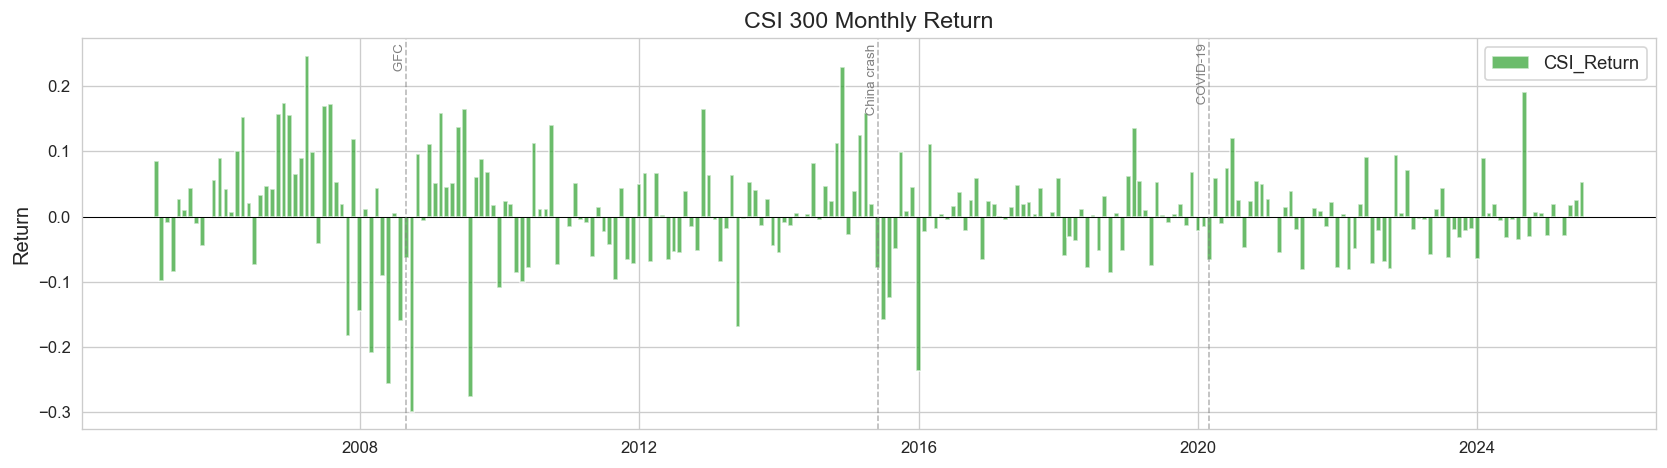

In [16]:
# ── 2c. CSI_Return ─────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(14, 4))
ax.bar(df.index, df['CSI_Return'], width=25, color=COLORS['ret'], alpha=0.7, label='CSI_Return')
ax.axhline(0, color='black', linewidth=0.6)
add_crisis_lines(ax)
ax.set_title('CSI 300 Monthly Return')
ax.set_ylabel('Return')
ax.legend()
plt.tight_layout()
plt.show()

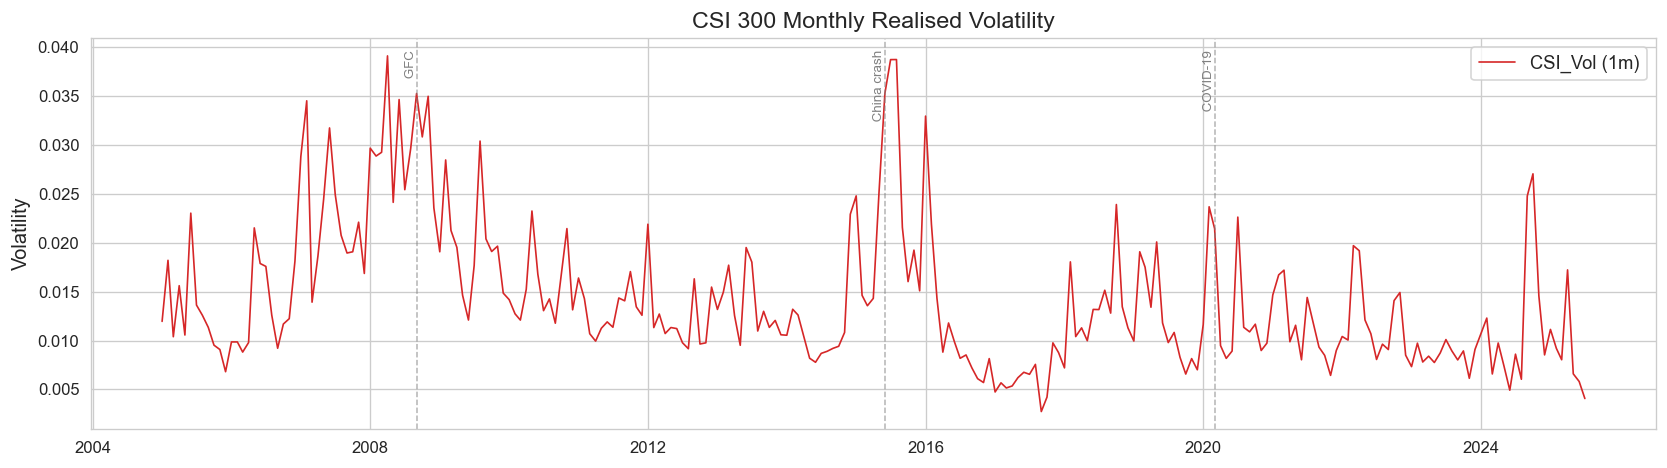

In [17]:
# ── 2d. CSI_Vol (monthly realised volatility) ──────────────────────
fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(df.index, df['CSI_Vol'], color=COLORS['vol'], linewidth=1.0, label='CSI_Vol (1m)')
add_crisis_lines(ax)
ax.set_title('CSI 300 Monthly Realised Volatility')
ax.set_ylabel('Volatility')
ax.legend()
plt.tight_layout()
plt.show()

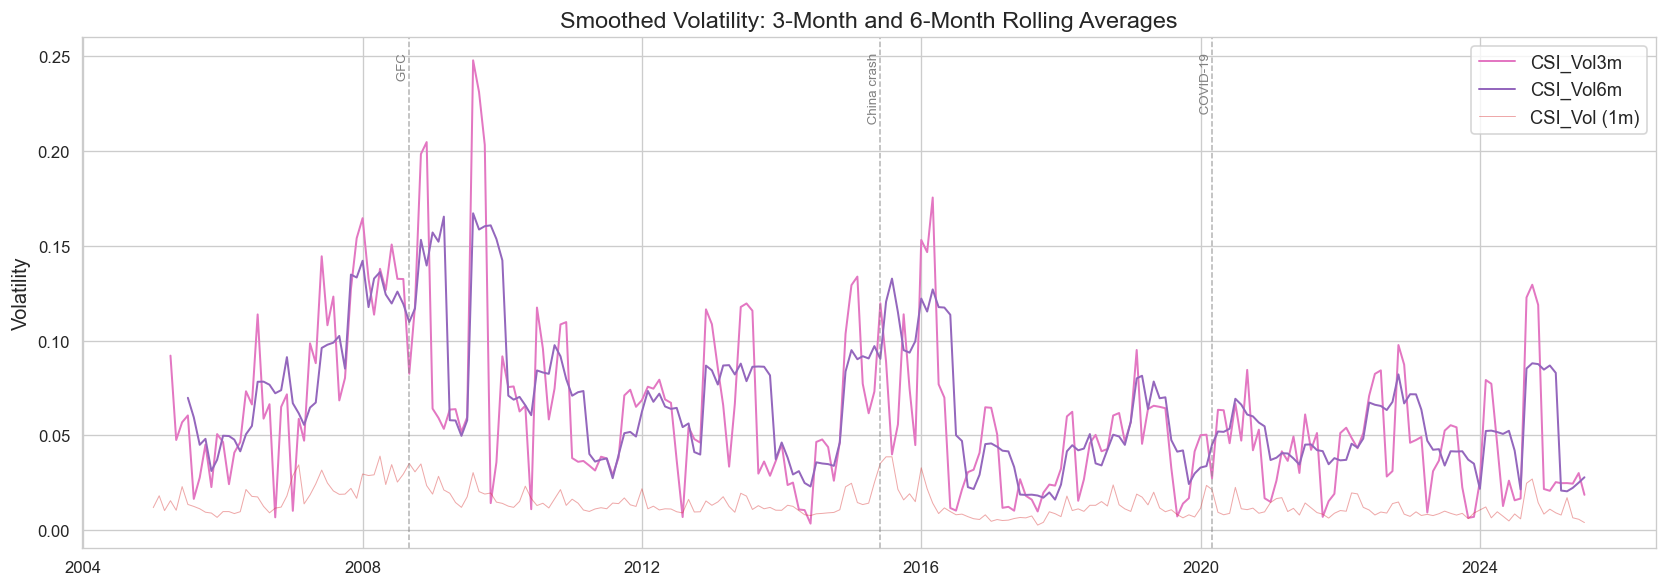

In [18]:
# ── 2e. CSI_Vol3m & CSI_Vol6m ──────────────────────────────────────
fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(df.index, df['CSI_Vol3m'], color='#e377c2', linewidth=1.2, label='CSI_Vol3m')
ax.plot(df.index, df['CSI_Vol6m'], color='#9467bd', linewidth=1.2, label='CSI_Vol6m')
ax.plot(df.index, df['CSI_Vol'], color=COLORS['vol'], linewidth=0.6, alpha=0.4, label='CSI_Vol (1m)')
add_crisis_lines(ax)
ax.set_title('Smoothed Volatility: 3-Month and 6-Month Rolling Averages')
ax.set_ylabel('Volatility')
ax.legend()
plt.tight_layout()
plt.show()

---
## 3. Distributions and Outliers

Understanding the distributional properties of the key variables is essential before correlation and regression analysis. Heavy tails (high kurtosis) and skewness affect the interpretation of Pearson correlations and OLS standard errors.

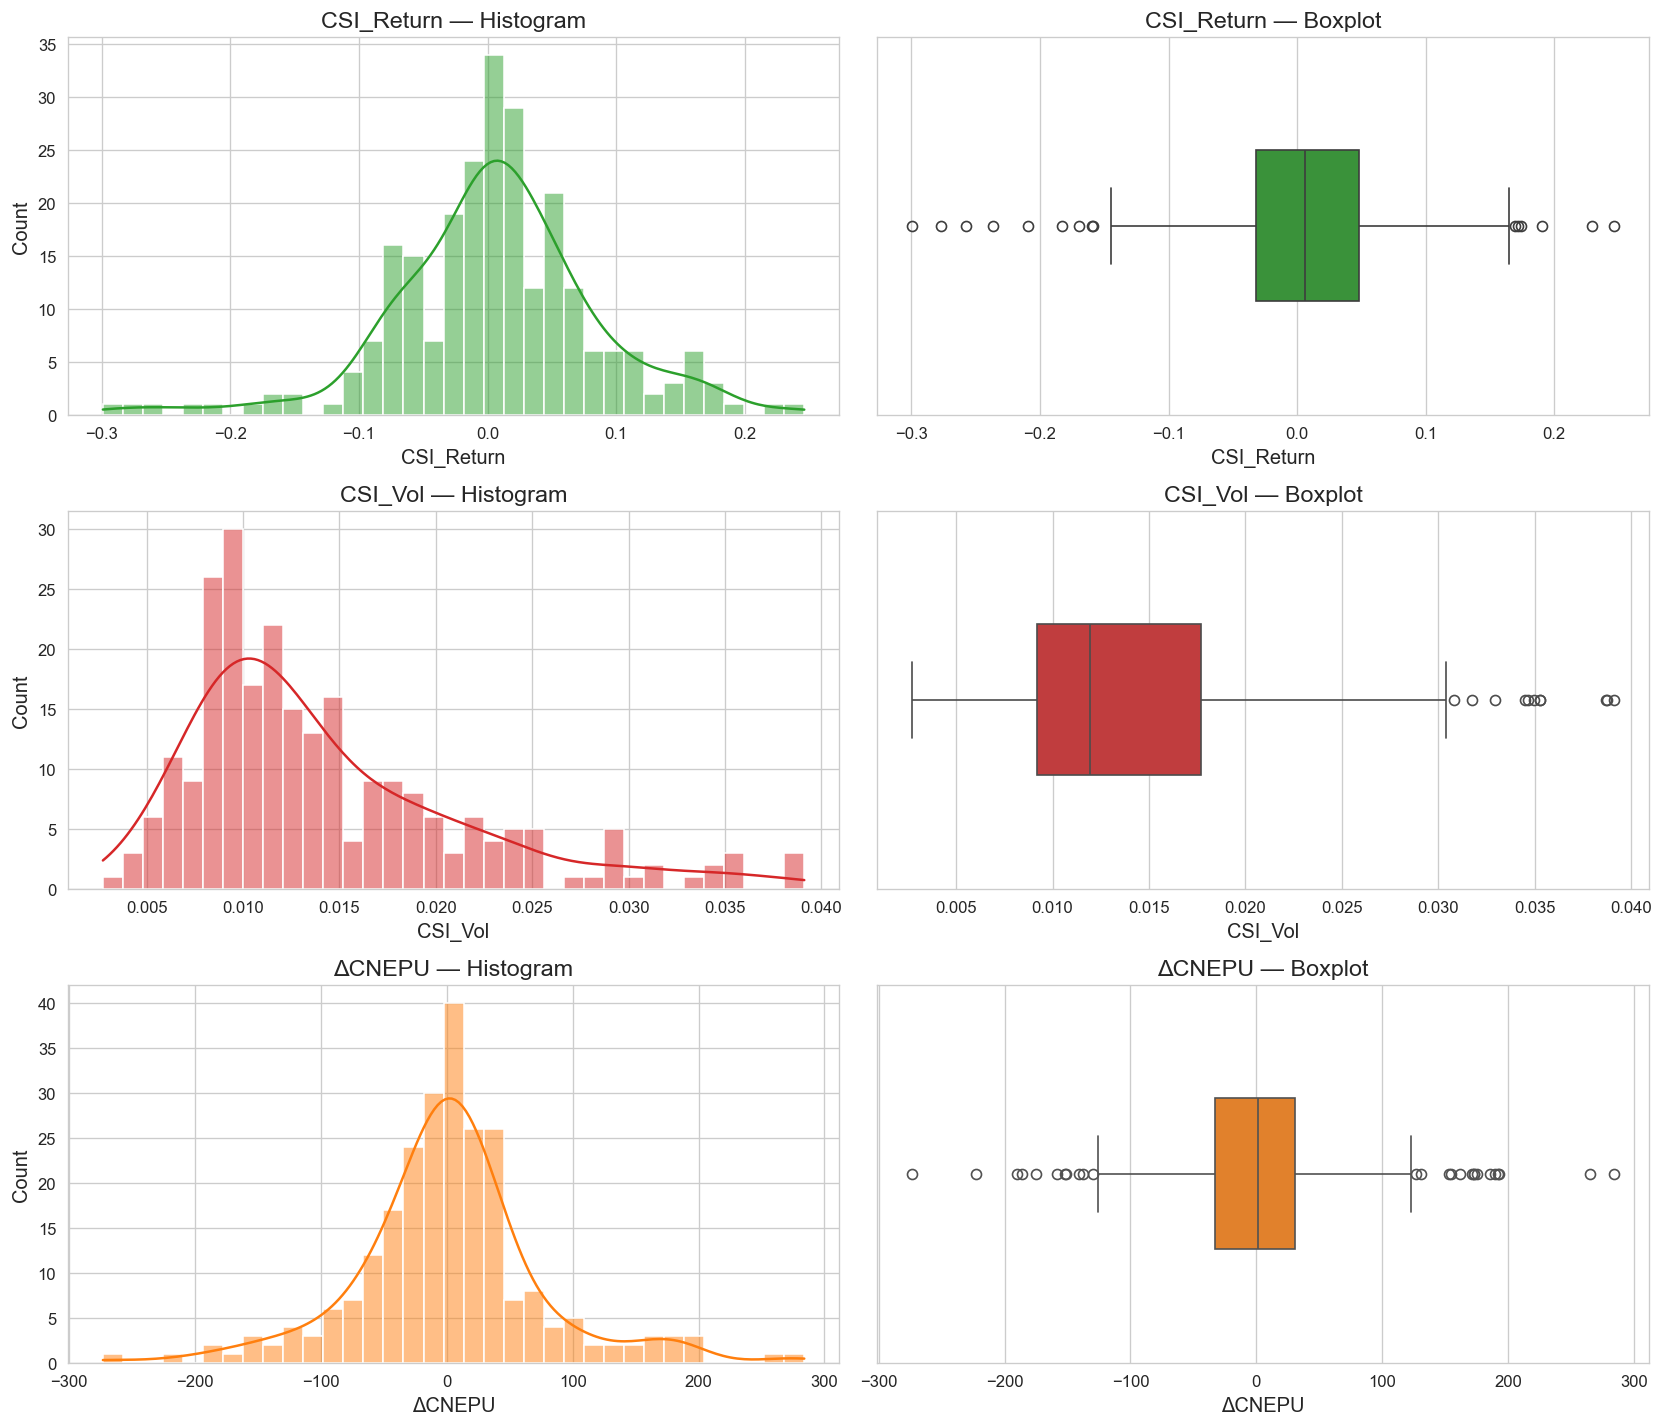

In [19]:
DIST_VARS = ['CSI_Return', 'CSI_Vol', 'ΔCNEPU']

fig, axes = plt.subplots(len(DIST_VARS), 2, figsize=(14, 4 * len(DIST_VARS)))

for i, var in enumerate(DIST_VARS):
    data = df[var].dropna()

    # Histogram + KDE
    ax_h = axes[i, 0]
    sns.histplot(data, bins=35, kde=True, ax=ax_h, color=COLORS.get(var.lower().replace('δcnepu','shock').replace('csi_return','ret').replace('csi_vol','vol'), '#1f77b4'))
    ax_h.set_title(f'{var} — Histogram')
    ax_h.set_xlabel(var)

    # Boxplot
    ax_b = axes[i, 1]
    sns.boxplot(x=data, ax=ax_b, color=COLORS.get(var.lower().replace('δcnepu','shock').replace('csi_return','ret').replace('csi_vol','vol'), '#1f77b4'), width=0.4)
    ax_b.set_title(f'{var} — Boxplot')
    ax_b.set_xlabel(var)

plt.tight_layout()
plt.show()

In [20]:
# ── Skewness & Kurtosis table ──────────────────────────────────────
from scipy.stats import skew, kurtosis  # only for descriptive stats

stats_table = pd.DataFrame({
    'mean':     [df[v].mean() for v in DIST_VARS],
    'std':      [df[v].std() for v in DIST_VARS],
    'skewness': [skew(df[v].dropna()) for v in DIST_VARS],
    'kurtosis': [kurtosis(df[v].dropna(), fisher=True) for v in DIST_VARS],
    'min':      [df[v].min() for v in DIST_VARS],
    'max':      [df[v].max() for v in DIST_VARS],
    'n':        [df[v].notna().sum() for v in DIST_VARS],
}, index=DIST_VARS)

display(stats_table.round(4))

,mean,std,skewness,kurtosis,min,max,n
CSI_Return,0.0060,0.0792,-0.3673,2.0096,-0.2991,0.2463,246
CSI_Vol,0.0142,0.0073,1.3259,1.4873,0.0027,0.0391,247
ΔCNEPU,1.2060,73.8880,0.2605,2.4822,-273.1702,283.9710,246


> **Interpretation:** If excess kurtosis > 0, the distribution has heavier tails than a Normal distribution. This is common in financial return and volatility series and implies that extreme observations carry disproportionate influence on Pearson correlations. Spearman (rank-based) correlations are more robust in this setting.

---
## 4. Correlation Analysis (Static)

We compute the full-sample pairwise correlation matrix under two estimators:

1. **Pearson** — captures linear association; sensitive to outliers and non-normality.  
2. **Spearman** — rank-based; robust to non-linear monotone relationships and heavy tails.

Divergence between the two matrices signals non-linearity or influential outliers.

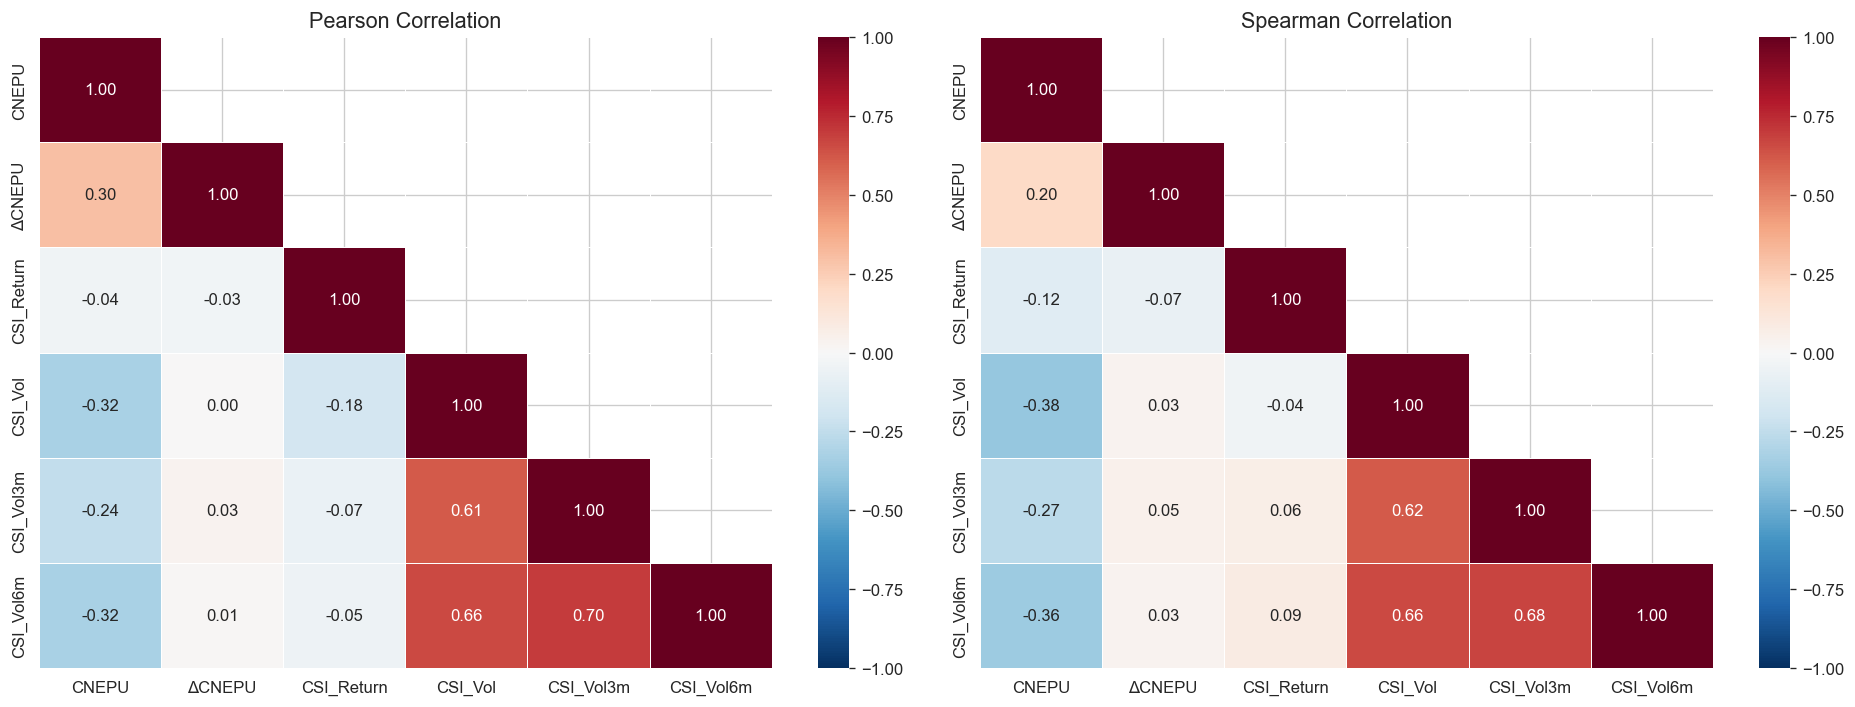

In [21]:
CORR_VARS = ['CNEPU', 'ΔCNEPU', 'CSI_Return', 'CSI_Vol', 'CSI_Vol3m', 'CSI_Vol6m']

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for ax, method, title in zip(axes,
                              ['pearson', 'spearman'],
                              ['Pearson Correlation', 'Spearman Correlation']):
    corr = df[CORR_VARS].corr(method=method)
    mask = np.triu(np.ones_like(corr, dtype=bool), k=1)
    sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r',
                center=0, vmin=-1, vmax=1, ax=ax, linewidths=0.5,
                annot_kws={'size': 10})
    ax.set_title(title, fontsize=13)

plt.tight_layout()
plt.show()

In [22]:
# ── Numeric comparison ─────────────────────────────────────────────
pearson  = df[CORR_VARS].corr(method='pearson')
spearman = df[CORR_VARS].corr(method='spearman')

diff = (spearman - pearson).round(3)
print('Spearman − Pearson (positive → Spearman stronger):')
display(diff)

Spearman − Pearson (positive → Spearman stronger):


,CNEPU,ΔCNEPU,CSI_Return,CSI_Vol,CSI_Vol3m,CSI_Vol6m
CNEPU,0.000,-0.102,-0.074,-0.061,-0.026,-0.039
ΔCNEPU,-0.102,0.000,-0.040,0.031,0.018,0.023
CSI_Return,-0.074,-0.040,0.000,0.143,0.130,0.135
CSI_Vol,-0.061,0.031,0.143,0.000,0.004,-0.000
CSI_Vol3m,-0.026,0.018,0.130,0.004,0.000,-0.025
CSI_Vol6m,-0.039,0.023,0.135,-0.000,-0.025,0.000


> **Key takeaway:** Where Spearman correlations are materially larger (in absolute value) than Pearson, the association is likely non-linear or driven by extreme observations. This motivates the use of both estimators in the formal analysis.

---
## 5. Quintile Analysis — Uncertainty Regimes

We divide observations into five equal-frequency bins (quintiles) based on CNEPU and ΔCNEPU. For each bin we compute the average market volatility and return to check whether the EPU–volatility relationship is **monotonic**, and whether extreme uncertainty (Q5) disproportionately amplifies risk.

In [23]:
def quintile_analysis(df, group_var, targets, labels_prefix='Q'):
    """
    Create quintiles of `group_var` and compute mean/median of `targets`.
    Returns a summary DataFrame.
    """
    tmp = df[[group_var] + targets].dropna()
    tmp['quintile'] = pd.qcut(tmp[group_var], 5,
                              labels=[f'{labels_prefix}{i}' for i in range(1, 6)])
    agg_funcs = {t: ['mean', 'median'] for t in targets}
    agg_funcs[group_var] = ['mean', 'count']
    summary = tmp.groupby('quintile').agg(agg_funcs).round(6)
    return summary, tmp

In [24]:
TARGETS = ['CSI_Vol', 'CSI_Vol3m', 'CSI_Vol6m', 'CSI_Return']

for gvar, title in [('CNEPU', 'CNEPU Level'), ('ΔCNEPU', 'ΔCNEPU Shock')]:
    summary, tmp = quintile_analysis(df.reset_index(), gvar, TARGETS)
    print(f'\n{"═" * 70}')
    print(f'  Quintile Summary — {title}')
    print(f'{"═" * 70}')
    display(summary)


══════════════════════════════════════════════════════════════════════
  Quintile Summary — CNEPU Level
══════════════════════════════════════════════════════════════════════


CSI_Vol           CSI_Vol3m           CSI_Vol6m            \
              mean    median      mean    median      mean    median   
quintile                                                               
Q1        0.017526  0.014943  0.070089  0.063869  0.075053  0.072816   
Q2        0.016228  0.014221  0.071266  0.057515  0.082876  0.086285   
Q3        0.014898  0.012645  0.069664  0.064512  0.073022  0.064645   
Q4        0.011167  0.009818  0.047889  0.039217  0.049674  0.042620   
Q5        0.011262  0.010101  0.044365  0.045743  0.049841  0.047968   

         CSI_Return                 CNEPU        
               mean    median        mean count  
quintile                                         
Q1         0.032510  0.033698   60.277162    49  
Q2         0.004095  0.014901  105.787928    48  
Q3        -0.014112 -0.005818  140.547100    48  
Q4         0.003553 -0.001499  233.688931    48  
Q5         0.005629  0.004297  389.657443    48


══════════════════════════════════════════════════════════════════════
  Quintile Summary — ΔCNEPU Shock
══════════════════════════════════════════════════════════════════════


CSI_Vol           CSI_Vol3m           CSI_Vol6m            \
              mean    median      mean    median      mean    median   
quintile                                                               
Q1        0.012728  0.011134  0.050943  0.046774  0.057610  0.051781   
Q2        0.014579  0.011532  0.061576  0.047238  0.068712  0.062963   
Q3        0.016094  0.014483  0.074370  0.066164  0.075660  0.073029   
Q4        0.015644  0.013348  0.063238  0.055048  0.071408  0.066952   
Q5        0.012138  0.010798  0.053545  0.047445  0.057440  0.049631   

         CSI_Return                ΔCNEPU        
               mean    median        mean count  
quintile                                         
Q1         0.020951  0.010499  -96.003105    49  
Q2         0.016959  0.015050  -24.066990    48  
Q3        -0.011960 -0.002226    0.805068    48  
Q4         0.007292 -0.003867   24.334423    48  
Q5        -0.001325  0.001419  103.153429    48

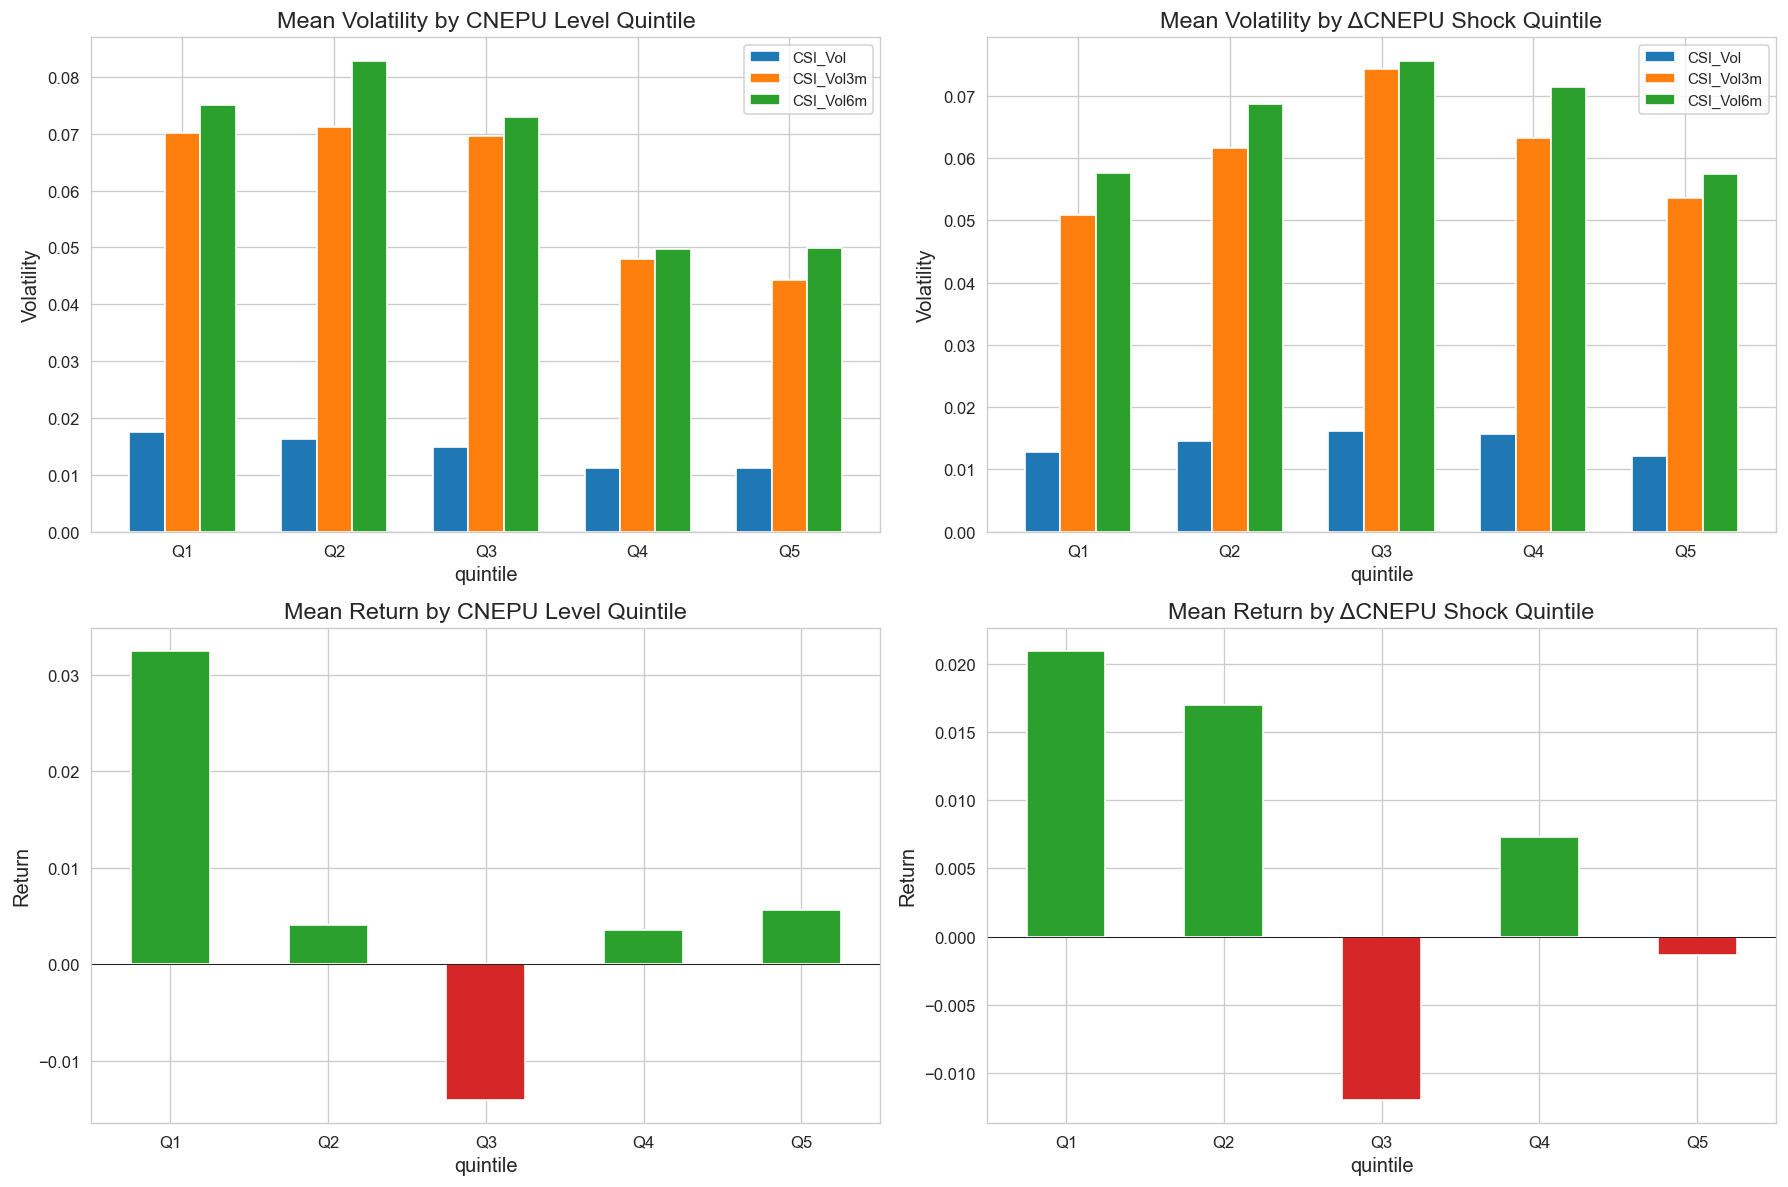

In [25]:
# ── Bar plots: volatility and return by quintile ───────────────────
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

for col_idx, (gvar, gvar_label) in enumerate([('CNEPU', 'CNEPU Level'),
                                                ('ΔCNEPU', 'ΔCNEPU Shock')]):
    _, tmp = quintile_analysis(df.reset_index(), gvar, TARGETS)

    # Volatility by quintile
    ax_v = axes[0, col_idx]
    vol_means = tmp.groupby('quintile')[['CSI_Vol', 'CSI_Vol3m', 'CSI_Vol6m']].mean()
    vol_means.plot.bar(ax=ax_v, rot=0, width=0.7)
    ax_v.set_title(f'Mean Volatility by {gvar_label} Quintile')
    ax_v.set_ylabel('Volatility')
    ax_v.legend(fontsize=9)

    # Return by quintile
    ax_r = axes[1, col_idx]
    ret_means = tmp.groupby('quintile')['CSI_Return'].mean()
    colors = ['#2ca02c' if v >= 0 else '#d62728' for v in ret_means]
    ret_means.plot.bar(ax=ax_r, color=colors, rot=0, width=0.5)
    ax_r.axhline(0, color='black', linewidth=0.5)
    ax_r.set_title(f'Mean Return by {gvar_label} Quintile')
    ax_r.set_ylabel('Return')

plt.tight_layout()
plt.show()

In [26]:
# ── Sample size per quintile ───────────────────────────────────────
for gvar in ['CNEPU', 'ΔCNEPU']:
    tmp = df[[gvar]].dropna().copy()
    tmp['quintile'] = pd.qcut(tmp[gvar], 5, labels=[f'Q{i}' for i in range(1, 6)])
    print(f'\nSample sizes — {gvar}:')
    print(tmp['quintile'].value_counts().sort_index())


Sample sizes — CNEPU:
quintile
Q1    50
Q2    49
Q3    49
Q4    49
Q5    50
Name: count, dtype: int64

Sample sizes — ΔCNEPU:
quintile
Q1    50
Q2    49
Q3    49
Q4    49
Q5    49
Name: count, dtype: int64


> **Interpretation:** A monotonically increasing pattern of volatility across CNEPU quintiles would be consistent with the *uncertainty–volatility hypothesis*. If the effect is concentrated in Q5 (highest uncertainty), the relationship may be non-linear and driven by tail events rather than a smooth gradient. Return patterns across quintiles may reveal an *uncertainty premium* (lower returns under higher uncertainty) but should be interpreted cautiously given the small sample size per bin.

---
## 6. Lead-Lag Analysis (Cross-Correlations with Lags)

A positive correlation at lag *k* between CNEPU$_{t-k}$ and CSI\_Vol$_t$ would suggest that elevated policy uncertainty **precedes** higher market volatility by *k* months — a prerequisite for predictive modelling.

We compute correlations for lags 0 through 12 and identify the lag with the strongest absolute association.

In [27]:
def lead_lag_corr(df, x_col, y_col, max_lag=12, method='pearson'):
    """
    Compute correlation between x_{t-k} and y_t for k = 0, ..., max_lag.
    Returns a DataFrame with lag, correlation, and p-value.
    """
    from scipy.stats import pearsonr, spearmanr
    corr_func = pearsonr if method == 'pearson' else spearmanr
    results = []
    for k in range(max_lag + 1):
        x_lagged = df[x_col].shift(k)
        valid = df[[y_col]].assign(x_lag=x_lagged).dropna()
        if len(valid) < 20:
            continue
        r, p = corr_func(valid['x_lag'], valid[y_col])
        results.append({'lag': k, 'corr': r, 'pvalue': p})
    return pd.DataFrame(results)

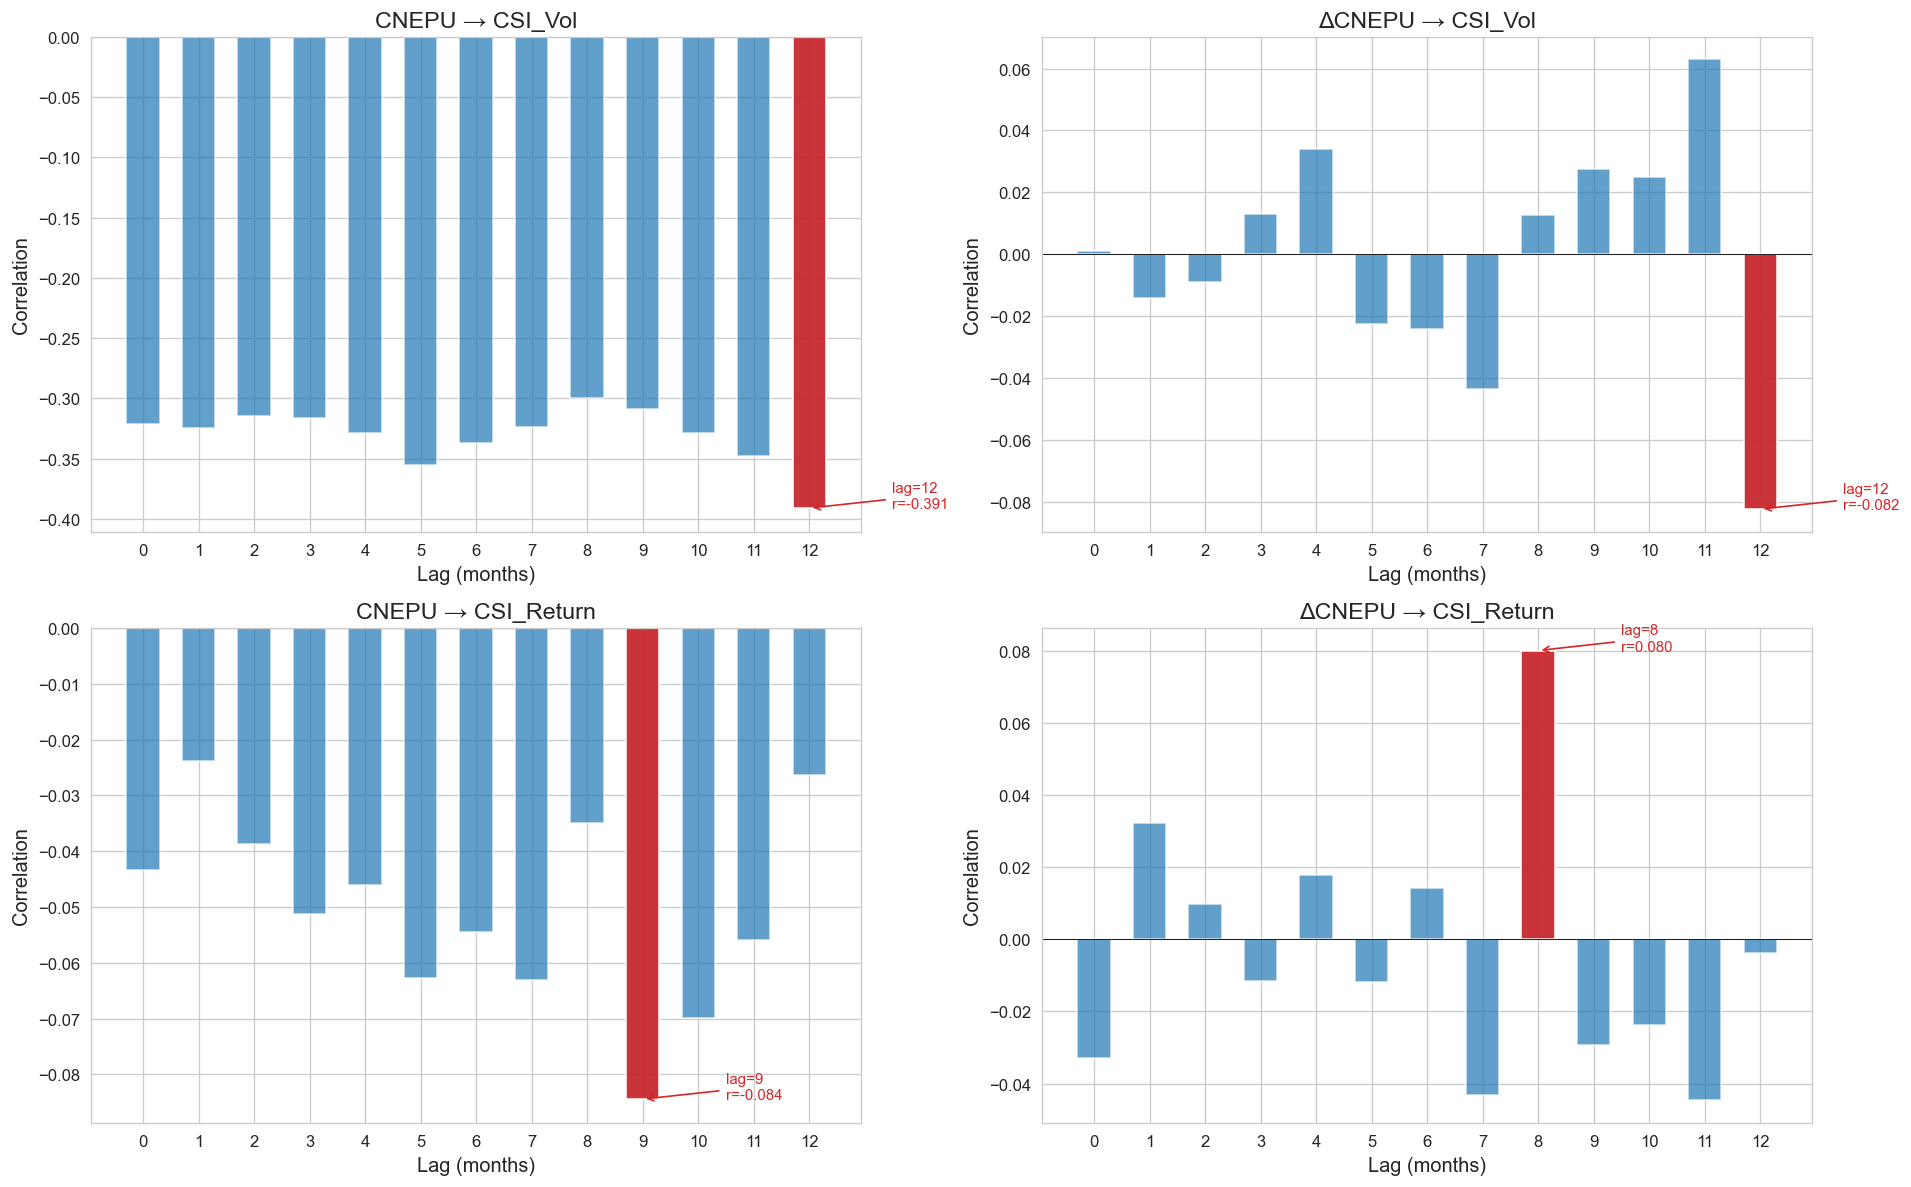

In [28]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

pairs = [
    ('CNEPU',  'CSI_Vol',    'CNEPU → CSI_Vol'),
    ('ΔCNEPU', 'CSI_Vol',    'ΔCNEPU → CSI_Vol'),
    ('CNEPU',  'CSI_Return', 'CNEPU → CSI_Return'),
    ('ΔCNEPU', 'CSI_Return', 'ΔCNEPU → CSI_Return'),
]

for ax, (x_col, y_col, title) in zip(axes.ravel(), pairs):
    ll = lead_lag_corr(df, x_col, y_col, max_lag=12)
    ax.bar(ll['lag'], ll['corr'], color=COLORS['epu'], alpha=0.7, width=0.6)
    ax.axhline(0, color='black', linewidth=0.5)

    # Mark max |corr|
    best_idx = ll['corr'].abs().idxmax()
    best_lag = ll.loc[best_idx, 'lag']
    best_r   = ll.loc[best_idx, 'corr']
    ax.bar(best_lag, best_r, color='#d62728', alpha=0.9, width=0.6)
    ax.annotate(f'lag={best_lag}\nr={best_r:.3f}',
                xy=(best_lag, best_r),
                xytext=(best_lag + 1.5, best_r),
                fontsize=9, color='#d62728',
                arrowprops=dict(arrowstyle='->', color='#d62728'))

    ax.set_title(title)
    ax.set_xlabel('Lag (months)')
    ax.set_ylabel('Correlation')
    ax.set_xticks(range(0, 13))

plt.tight_layout()
plt.show()

In [29]:
# ── Numeric lead-lag table ─────────────────────────────────────────
for x_col, y_col, title in pairs:
    ll = lead_lag_corr(df, x_col, y_col, max_lag=12)
    print(f'\n{title}')
    display(ll.set_index('lag').round(4).T)


CNEPU → CSI_Vol


lag,0,1,2,3,4,5,6,7,8,9,10,11,12
corr,-0.3214,-0.3246,-0.315,-0.3164,-0.329,-0.3553,-0.3374,-0.3235,-0.2996,-0.3092,-0.329,-0.3477,-0.3911
pvalue,0.0000,0.0000,0.000,0.0000,0.000,0.0000,0.0000,0.0000,0.0000,0.0000,0.000,0.0000,0.0000



ΔCNEPU → CSI_Vol


lag,0,1,2,3,4,5,6,7,8,9,10,11,12
corr,0.0010,-0.0143,-0.0089,0.0131,0.0340,-0.0227,-0.0241,-0.0438,0.0126,0.0274,0.0248,0.0629,-0.0825
pvalue,0.9878,0.8239,0.8899,0.8391,0.5982,0.7260,0.7098,0.5009,0.8469,0.6748,0.7044,0.3369,0.2089



CNEPU → CSI_Return


lag,0,1,2,3,4,5,6,7,8,9,10,11,12
corr,-0.0434,-0.0238,-0.0388,-0.0513,-0.0461,-0.0628,-0.0545,-0.0631,-0.0350,-0.0844,-0.0698,-0.0560,-0.0263
pvalue,0.4981,0.7106,0.5457,0.4252,0.4747,0.3309,0.3992,0.3305,0.5901,0.1943,0.2844,0.3918,0.6879



ΔCNEPU → CSI_Return


lag,0,1,2,3,4,5,6,7,8,9,10,11,12
corr,-0.0329,0.0322,0.0099,-0.0115,0.0178,-0.0118,0.0144,-0.0432,0.0800,-0.0292,-0.0238,-0.0446,-0.0039
pvalue,0.6071,0.6156,0.8782,0.8588,0.7833,0.8556,0.8249,0.5059,0.2187,0.6549,0.7165,0.4964,0.9528


> **Interpretation:**  
> - If the highest absolute correlation appears at **lag 0**, the relationship is predominantly contemporaneous.  
> - A peak at **lags 1–3** is encouraging for 1-to-3-month-ahead volatility forecasting.  
> - Rapid decay of correlations beyond lag 3 is common for macroeconomic signals at monthly frequency.

---
## 7. Rolling Correlations — Time-Varying Association

Full-sample correlations can mask substantial temporal variation. Rolling-window correlations reveal whether the EPU–volatility association strengthens during crises and weakens in calm regimes.

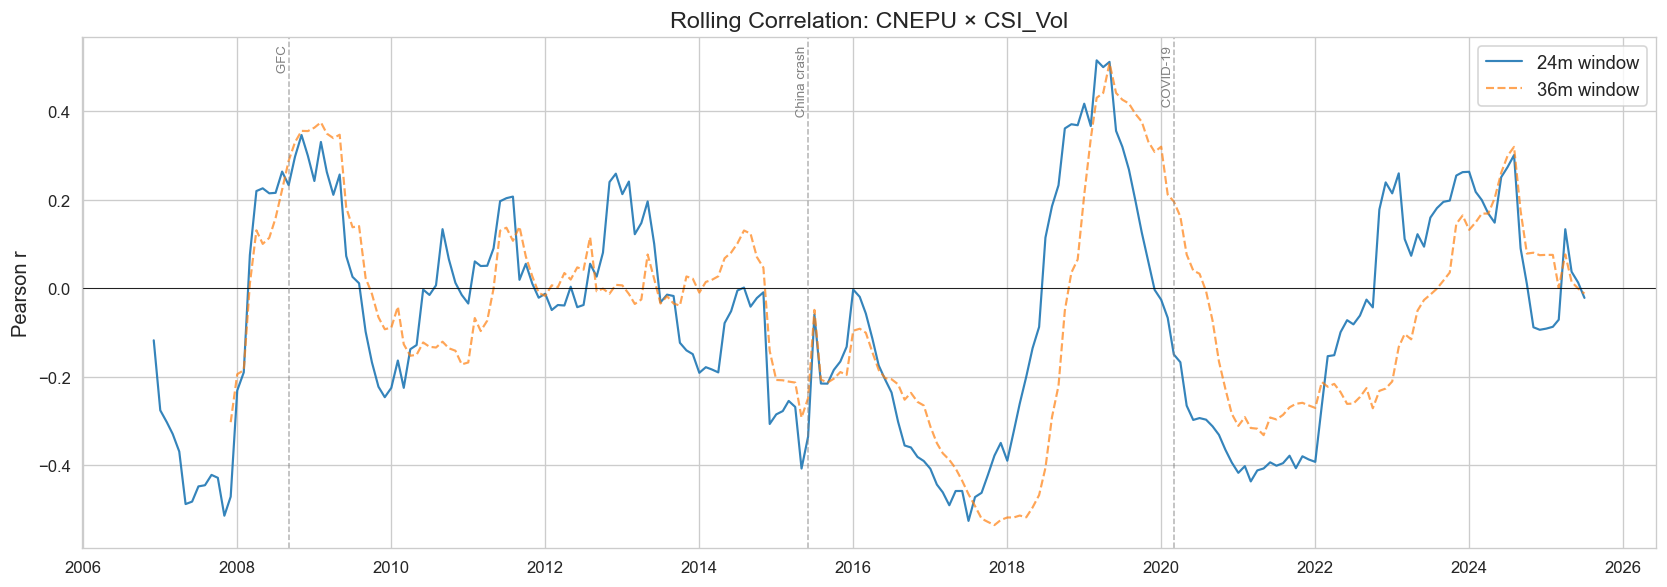

In [30]:
fig, ax = plt.subplots(figsize=(14, 5))

for window, ls, alpha in [(24, '-', 0.9), (36, '--', 0.7)]:
    rolling_corr = df['CNEPU'].rolling(window).corr(df['CSI_Vol'])
    ax.plot(df.index, rolling_corr, linewidth=1.3, linestyle=ls,
            alpha=alpha, label=f'{window}m window')

ax.axhline(0, color='black', linewidth=0.5)
add_crisis_lines(ax)
ax.set_title('Rolling Correlation: CNEPU × CSI_Vol')
ax.set_ylabel('Pearson r')
ax.legend()
plt.tight_layout()
plt.show()

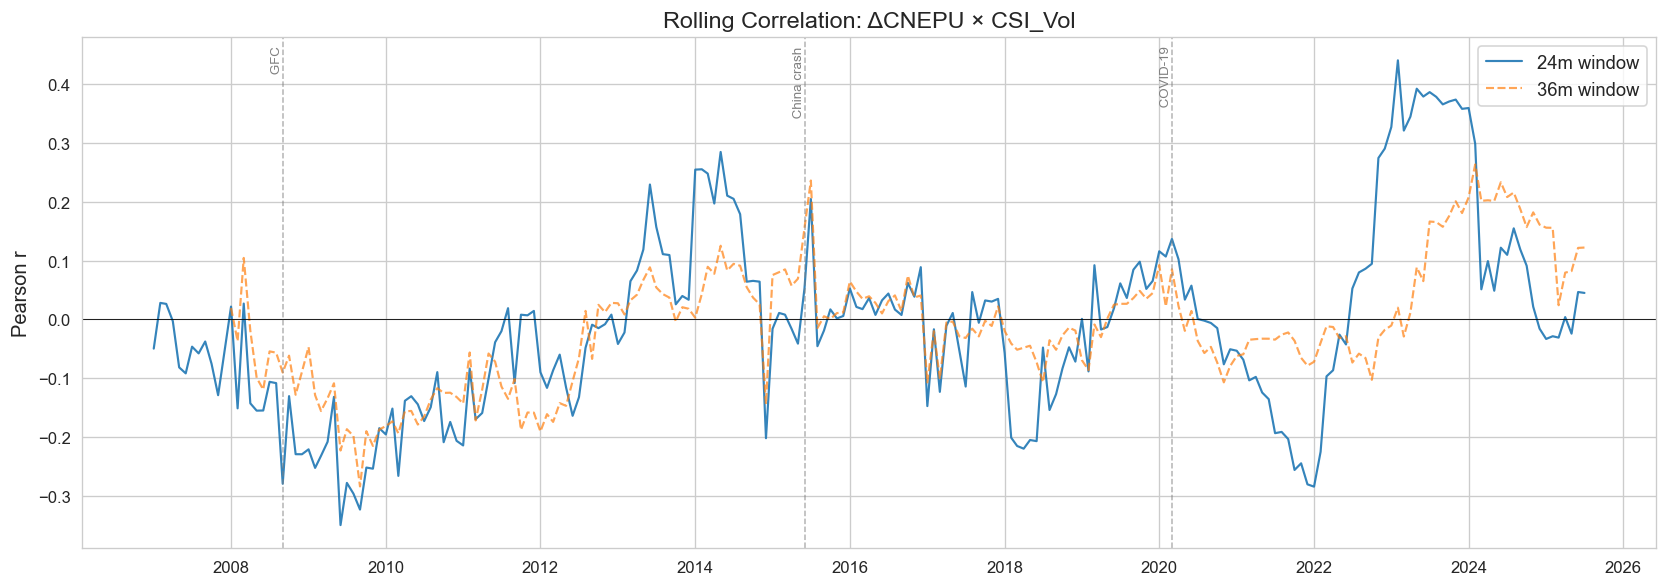

In [31]:
# ── Rolling correlation for ΔCNEPU × CSI_Vol ───────────────────────
fig, ax = plt.subplots(figsize=(14, 5))

for window, ls, alpha in [(24, '-', 0.9), (36, '--', 0.7)]:
    rolling_corr = df['ΔCNEPU'].rolling(window).corr(df['CSI_Vol'])
    ax.plot(df.index, rolling_corr, linewidth=1.3, linestyle=ls,
            alpha=alpha, label=f'{window}m window')

ax.axhline(0, color='black', linewidth=0.5)
add_crisis_lines(ax)
ax.set_title('Rolling Correlation: ΔCNEPU × CSI_Vol')
ax.set_ylabel('Pearson r')
ax.legend()
plt.tight_layout()
plt.show()

> **Interpretation:** Episodes where the rolling correlation spikes upward coincide with periods of market stress (e.g., 2008, 2015, 2020). This is consistent with the *leverage effect* and suggests that the EPU–volatility association is regime-dependent — an important consideration for model specification.

---
## 8. Subperiod Analysis — Structural Robustness

To test whether the observed associations are stable over time, we split the sample into three non-overlapping subperiods:

| Period | Range | Key characteristics |
|--------|-------|---------------------|
| I | 2005 – 2012 | GFC, post-crisis recovery |
| II | 2013 – 2019 | A-share market boom and crash, trade tensions |
| III | 2020 – present | COVID-19, post-pandemic |

For each subperiod we report correlations and average levels of volatility and EPU.

In [32]:
SUBPERIODS = {
    'I  (2005–2012)':  ('2005-01-01', '2012-12-31'),
    'II (2013–2019)':  ('2013-01-01', '2019-12-31'),
    'III (2020–last)': ('2020-01-01', df.index.max().strftime('%Y-%m-%d')),
}

rows = []
for label, (start, end) in SUBPERIODS.items():
    sub = df.loc[start:end].dropna(subset=['CNEPU', 'CSI_Vol'])
    rows.append({
        'Period': label,
        'N': len(sub),
        'CNEPU_mean': sub['CNEPU'].mean(),
        'CSI_Vol_mean': sub['CSI_Vol'].mean(),
        'CSI_Return_mean': sub['CSI_Return'].mean(),
        'Corr(CNEPU, CSI_Vol)_pearson':  sub['CNEPU'].corr(sub['CSI_Vol'], method='pearson'),
        'Corr(ΔCNEPU, CSI_Vol)_pearson': sub['ΔCNEPU'].corr(sub['CSI_Vol'], method='pearson'),
        'Corr(CNEPU, CSI_Vol)_spearman': sub['CNEPU'].corr(sub['CSI_Vol'], method='spearman'),
    })

subperiod_table = pd.DataFrame(rows).set_index('Period')
display(subperiod_table.round(4))

,N,CNEPU_mean,CSI_Vol_mean,CSI_Return_mean,"Corr(CNEPU, CSI_Vol)_pearson","Corr(ΔCNEPU, CSI_Vol)_pearson","Corr(CNEPU, CSI_Vol)_spearman"
Period,,,,,,,
I (2005–2012),96,93.4926,0.0175,0.0102,-0.0337,-0.0528,-0.0143
II (2013–2019),84,181.5656,0.0130,0.0058,-0.1941,0.0177,-0.3032
III (2020–last),67,309.7178,0.0111,0.0002,-0.0852,0.0129,-0.0352


> **Interpretation:** Consistent sign and magnitude of the EPU–volatility correlation across subperiods supports a **robust association**. Substantial variation may indicate a **structural break** — potentially driven by regulatory changes or a shift in the information content of the EPU index. Note that the post-2020 subsample is the shortest and most affected by the COVID-19 shock, so its statistics should be interpreted with caution.

---
## 9. EDA Conclusions

The following bullet points synthesise the main patterns uncovered in this exploratory analysis. They serve as motivation and guidance for the predictive-modelling stage (Phase 3).

*(To be filled after executing all cells above — the code below generates an automated summary.)*

In [33]:
# ── Automated summary statistics for conclusions ───────────────────
print('━' * 70)
print('  SUMMARY STATISTICS FOR CONCLUSIONS')
print('━' * 70)

# 1. Full-sample correlations
print('\n1. Full-sample Pearson correlations (CNEPU, CSI_Vol):')
r_cnepu_vol  = df['CNEPU'].corr(df['CSI_Vol'])
r_dcnepu_vol = df['ΔCNEPU'].corr(df['CSI_Vol'])
print(f'   CNEPU  ↔ CSI_Vol  : {r_cnepu_vol:.4f}')
print(f'   ΔCNEPU ↔ CSI_Vol  : {r_dcnepu_vol:.4f}')

# 2. Best lag
ll_level = lead_lag_corr(df, 'CNEPU', 'CSI_Vol', max_lag=12)
ll_shock = lead_lag_corr(df, 'ΔCNEPU', 'CSI_Vol', max_lag=12)
best_level = ll_level.loc[ll_level['corr'].abs().idxmax()]
best_shock = ll_shock.loc[ll_shock['corr'].abs().idxmax()]
print(f'\n2. Best lag (CNEPU  → CSI_Vol) : lag={int(best_level["lag"])}, r={best_level["corr"]:.4f}')
print(f'   Best lag (ΔCNEPU → CSI_Vol) : lag={int(best_shock["lag"])}, r={best_shock["corr"]:.4f}')

# 3. Volatility comparison Q1 vs Q5 (CNEPU)
_, tmp_q = quintile_analysis(df.reset_index(), 'CNEPU', ['CSI_Vol'])
vol_q1 = tmp_q[tmp_q['quintile'] == 'Q1']['CSI_Vol'].mean()
vol_q5 = tmp_q[tmp_q['quintile'] == 'Q5']['CSI_Vol'].mean()
print(f'\n3. Mean CSI_Vol in CNEPU Q1: {vol_q1:.6f}')
print(f'   Mean CSI_Vol in CNEPU Q5: {vol_q5:.6f}')
print(f'   Ratio Q5/Q1: {vol_q5/vol_q1:.2f}x')

# 4. Vol comparison: 1m vs 3m vs 6m correlations with CNEPU
r_1m = df['CNEPU'].corr(df['CSI_Vol'])
r_3m = df['CNEPU'].corr(df['CSI_Vol3m'])
r_6m = df['CNEPU'].corr(df['CSI_Vol6m'])
print(f'\n4. Corr(CNEPU, CSI_Vol)   : {r_1m:.4f}')
print(f'   Corr(CNEPU, CSI_Vol3m) : {r_3m:.4f}')
print(f'   Corr(CNEPU, CSI_Vol6m) : {r_6m:.4f}')

# 5. Sample size
print(f'\n5. Total observations: {len(df)}')
print(f'   Complete cases (no NaN in core vars): {df[["CNEPU", "ΔCNEPU", "CSI_Vol", "CSI_Return"]].dropna().shape[0]}')

print('\n' + '━' * 70)

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  SUMMARY STATISTICS FOR CONCLUSIONS
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

1. Full-sample Pearson correlations (CNEPU, CSI_Vol):
   CNEPU  ↔ CSI_Vol  : -0.3214
   ΔCNEPU ↔ CSI_Vol  : 0.0010

2. Best lag (CNEPU  → CSI_Vol) : lag=12, r=-0.3911
   Best lag (ΔCNEPU → CSI_Vol) : lag=12, r=-0.0825

3. Mean CSI_Vol in CNEPU Q1: 0.017115
   Mean CSI_Vol in CNEPU Q5: 0.011184
   Ratio Q5/Q1: 0.65x

4. Corr(CNEPU, CSI_Vol)   : -0.3214
   Corr(CNEPU, CSI_Vol3m) : -0.2448
   Corr(CNEPU, CSI_Vol6m) : -0.3234

5. Total observations: 247
   Complete cases (no NaN in core vars): 246

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━


---
*End of Phase 2: Exploratory Data Analysis — China EPU × CSI 300*